In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
df = pd.DataFrame({
    "x1": [1,2,3,4,5,6,7,8,9,10],
    "x2": [21,73,34,95,86,75,80,19,100,161],
    "label": [0,0,0,0,1,1,1,1,1,1]
})

df.head()

,x1,x2,label
0,1,21,0
1,2,73,0
2,3,34,0
3,4,95,0
4,5,86,1


In [6]:
X = df[["x1", "x2"]].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8, 2)
(2, 2)


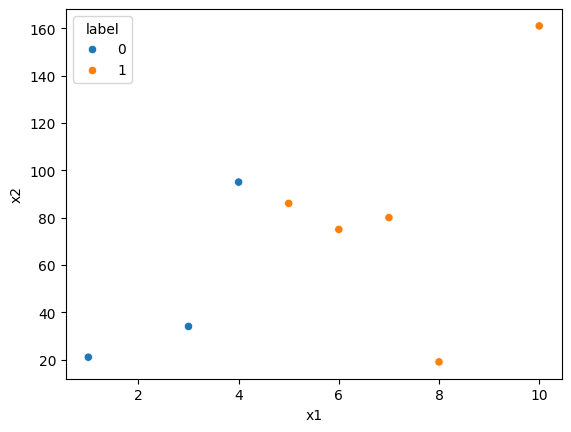

In [7]:
X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)

plt.show()

In [8]:
class KNNClassifier:

    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict_one(self, x):

        distances = [
            self._euclidean_dist(x, x_train)
            for x_train in self.X_train
        ]

        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))

        return majority_class

    def predict(self, X):
        y_pred = [self.predict_one(x) for x in X]
        return np.array(y_pred)

In [9]:
knn = KNNClassifier(k=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions:", y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Predictions: [1 1]
Accuracy: 0.5


In [10]:
arr = [0,0,1,1,2,3,4,3,4,4,4]
np.bincount(arr)
np.argmax(np.bincount(arr))

np.int64(4)